In [1]:
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -------------------------------------------------------
# Input directories
# -------------------------------------------------------
ARI_dir    = r"C:\Data_for_Code\ARI_mARI_07-25-07-30-B5.tif"
Aspect_dir = r"C:\Data_for_Code\aspect_10m_new.tif"
NLCD_dir   = r"C:\Data_for_Code\Annual_NLCD_LndCov_2023_CU_C1V1_d6d481be-09e8-43df-8355-b0802c92b892.tiff"

# NLCD class to restrict analysis to
DECIDUOUS = 41

# -------------------------------------------------------
# Aspect class definitions
# Aspect is in degrees (0-360); -1 is Flat (ArcGIS/GDAL convention).
# -------------------------------------------------------
ASPECT_CLASSES = [
    "Flat",
    "North",
    "Northeast",
    "East",
    "Southeast",
    "South",
    "Southwest",
    "West",
    "Northwest",
]

# Colour palette (one per class, in ASPECT_CLASSES order)
CLASS_COLORS = [
    "#a6a6a6",  # Flat        - grey
    "#2166ac",  # North       - dark blue
    "#74add1",  # Northeast   - light blue
    "#4dac26",  # East        - green
    "#b8e186",  # Southeast   - light green
    "#d73027",  # South       - red
    "#f46d43",  # Southwest   - orange-red
    "#fdae61",  # West        - orange
    "#abd9e9",  # Northwest   - pale blue
]

In [2]:
# -------------------------------------------------------
# Read ARI raster (10 m) - bands 1=ARI, 2=mARI, 3=Redness
# -------------------------------------------------------
with rasterio.open(ARI_dir) as src:
    ari_profile   = src.profile
    ari_crs       = src.crs
    ari_transform = src.transform
    ari_shape     = (src.height, src.width)
    ari_nodata    = src.nodata

    b1 = src.read(1).astype(np.float32)   # ARI
    b2 = src.read(2).astype(np.float32)   # mARI
    b3 = src.read(3).astype(np.float32)   # Redness

# Valid pixels mask for the three index bands
valid_idx = np.isfinite(b1) & np.isfinite(b2) & np.isfinite(b3)
if ari_nodata is not None:
    valid_idx &= (b1 != ari_nodata) & (b2 != ari_nodata) & (b3 != ari_nodata)

print(f"ARI grid             : {ari_shape[0]} rows x {ari_shape[1]} cols")
print(f"Valid ARI pixels     : {valid_idx.sum():,}")

ARI grid             : 502 rows x 610 cols
Valid ARI pixels     : 297,760


In [3]:
# -------------------------------------------------------
# Reproject NLCD (30 m) -> ARI grid (10 m), nearest neighbour
# Then restrict valid_idx to deciduous forest pixels only
# -------------------------------------------------------
nlcd_on_ari = np.full(ari_shape, fill_value=0, dtype=np.uint8)

with rasterio.open(NLCD_dir) as nl:
    nl_arr    = nl.read(1)
    nl_nodata = nl.nodata

    reproject(
        source        = nl_arr,
        destination   = nlcd_on_ari,
        src_transform = nl.transform,
        src_crs       = nl.crs,
        dst_transform = ari_transform,
        dst_crs       = ari_crs,
        resampling    = Resampling.nearest,
        src_nodata    = nl_nodata,
        dst_nodata    = 0,
    )

# Restrict the valid mask to deciduous forest only (NLCD class 41)
is_deciduous = (nlcd_on_ari == DECIDUOUS)
valid_idx    = valid_idx & is_deciduous

print(f"Deciduous pixels (NLCD 41)           : {is_deciduous.sum():,}")
print(f"Deciduous pixels with valid ARI data : {valid_idx.sum():,}")

Deciduous pixels (NLCD 41)           : 121,604
Deciduous pixels with valid ARI data : 121,280


In [4]:
# -------------------------------------------------------
# Read & reproject Aspect raster onto ARI grid
# Aspect may already be 10 m; reproject ensures alignment.
# -------------------------------------------------------
aspect_on_ari = np.full(ari_shape, fill_value=np.nan, dtype=np.float32)

with rasterio.open(Aspect_dir) as asp:
    asp_arr    = asp.read(1).astype(np.float32)
    asp_nodata = asp.nodata

    # Replace nodata with NaN before reprojection
    if asp_nodata is not None:
        asp_arr[asp_arr == asp_nodata] = np.nan

    reproject(
        source        = asp_arr,
        destination   = aspect_on_ari,
        src_transform = asp.transform,
        src_crs       = asp.crs,
        dst_transform = ari_transform,
        dst_crs       = ari_crs,
        resampling    = Resampling.bilinear,
        src_nodata    = np.nan,
        dst_nodata    = np.nan,
    )

print(f"Aspect range after reproject: {np.nanmin(aspect_on_ari):.1f} - {np.nanmax(aspect_on_ari):.1f} degrees")

Aspect range after reproject: 9.0 - 354.1 degrees


In [5]:
# -------------------------------------------------------
# Classify aspect into 9 named classes
# Values < 0 (e.g. -1) -> Flat
# 337.5-360 wraps back to North
# -------------------------------------------------------
def classify_aspect(asp_deg):
    out   = np.full(asp_deg.shape, "", dtype=object)
    valid = np.isfinite(asp_deg)

    out[valid & (asp_deg < 0)]                          = "Flat"
    out[valid & (asp_deg >=   0.0) & (asp_deg <  22.5)] = "North"
    out[valid & (asp_deg >=  22.5) & (asp_deg <  67.5)] = "Northeast"
    out[valid & (asp_deg >=  67.5) & (asp_deg < 112.5)] = "East"
    out[valid & (asp_deg >= 112.5) & (asp_deg < 157.5)] = "Southeast"
    out[valid & (asp_deg >= 157.5) & (asp_deg < 202.5)] = "South"
    out[valid & (asp_deg >= 202.5) & (asp_deg < 247.5)] = "Southwest"
    out[valid & (asp_deg >= 247.5) & (asp_deg < 292.5)] = "West"
    out[valid & (asp_deg >= 292.5) & (asp_deg < 337.5)] = "Northwest"
    out[valid & (asp_deg >= 337.5) & (asp_deg <= 360.0)] = "North"  # wraps
    return out

aspect_class = classify_aspect(aspect_on_ari)

# Report pixel counts per class (within deciduous mask only)
print("Aspect class pixel counts (deciduous NLCD 41 only):")
for cls in ASPECT_CLASSES:
    n = (valid_idx & (aspect_class == cls)).sum()
    print(f"  {cls:>12s} : {n:>10,} pixels")

Aspect class pixel counts (deciduous NLCD 41 only):
          Flat :          0 pixels
         North :         89 pixels
     Northeast :      2,519 pixels
          East :     11,372 pixels
     Southeast :     18,943 pixels
         South :     19,435 pixels
     Southwest :     18,042 pixels
          West :     12,079 pixels
     Northwest :      3,177 pixels


In [6]:
# -------------------------------------------------------
# Build DataFrame - one row per valid deciduous pixel
# -------------------------------------------------------
rows = []
for cls in ASPECT_CLASSES:
    mask = valid_idx & (aspect_class == cls)
    n    = mask.sum()
    if n == 0:
        continue
    rows.append(pd.DataFrame({
        "aspect_class" : cls,
        "ARI"          : b1[mask],
        "mARI"         : b2[mask],
        "Redness"      : b3[mask],
    }))

df = pd.concat(rows, ignore_index=True)

# Enforce the display order as a Categorical
df["aspect_class"] = pd.Categorical(df["aspect_class"],
                                     categories=ASPECT_CLASSES,
                                     ordered=True)
df = df.sort_values("aspect_class").reset_index(drop=True)

print(f"Total deciduous pixels in DataFrame : {len(df):,}")
print(df.groupby("aspect_class", observed=True).size().to_string())

Total deciduous pixels in DataFrame : 85,656
aspect_class
North           89
Northeast     2519
East         11372
Southeast    18943
South        19435
Southwest    18042
West         12079
Northwest     3177


In [7]:
# -------------------------------------------------------
# Summary statistics per aspect class
# -------------------------------------------------------
summary = df.groupby("aspect_class", observed=True)[["ARI", "mARI", "Redness"]].describe()
print(summary.round(4).to_string())

                  ARI                                                              mARI                                                          Redness                                                        
                count    mean     std     min     25%     50%     75%      max    count    mean     std     min     25%     50%     75%     max    count    mean     std     min     25%     50%     75%     max
aspect_class                                                                                                                                                                                                    
North            89.0  8.6576  1.6000  5.7115  7.4885  8.4769  9.4349  16.6616     89.0  2.9264  0.4890  0.7802  2.6723  2.9063  3.2334  3.9457     89.0 -0.2939  0.0398 -0.3553 -0.3178 -0.2977 -0.2800 -0.1486
Northeast      2519.0  8.7068  1.6221 -0.4505  7.8238  8.7366  9.6801  14.7390   2519.0  2.9887  0.5943 -0.0541  2.7106  3.0464  3.3556  4.6853   2519.0 -0.2902  0.

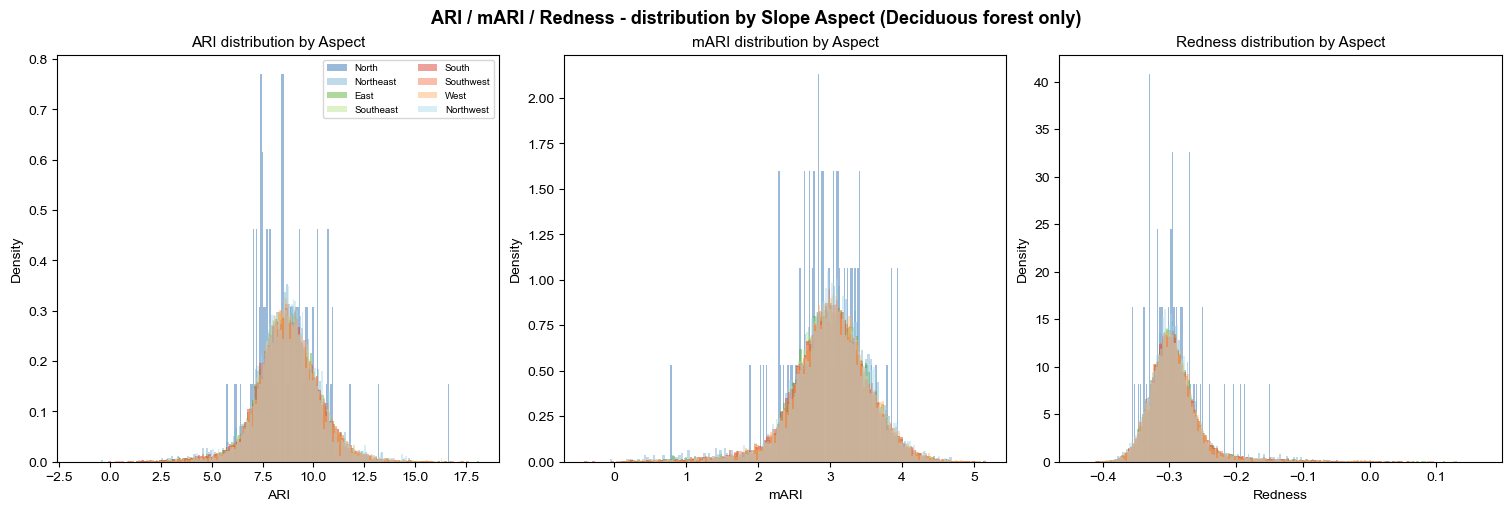

Figure 1 saved.


In [8]:
# -------------------------------------------------------
# FIGURE 1 - Overlapping density histograms
# One panel per index; each aspect class = one histogram
# -------------------------------------------------------
plt.rcParams['font.family'] = 'Arial'

color_map = dict(zip(ASPECT_CLASSES, CLASS_COLORS))
present_classes = [c for c in ASPECT_CLASSES
                   if c in df["aspect_class"].cat.categories
                   and (df["aspect_class"] == c).sum() > 0]

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for j, col in enumerate(["ARI", "mARI", "Redness"]):
    ax = axes1[j]
    for cls in present_classes:
        vals = df.loc[df["aspect_class"] == cls, col].values
        ax.hist(vals, bins=150, alpha=0.45, density=True,
                color=color_map[cls], label=cls)
    ax.set_title(f"{col} distribution by Aspect", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    if j == 0:
        ax.legend(fontsize=7, ncol=2)

fig1.suptitle("ARI / mARI / Redness - distribution by Slope Aspect (Deciduous forest only)",
              fontsize=13, fontweight='bold')
plt.savefig(r"C:\Data_for_Code\ARI_aspect_deciduous_histograms.png", dpi=200, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

C:\Users\aglyl\AppData\Local\Temp\ipykernel_31352\2470581779.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\aglyl\AppData\Local\Temp\ipykernel_31352\2470581779.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\aglyl\AppData\Local\Temp\ipykernel_31352\2470581779.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


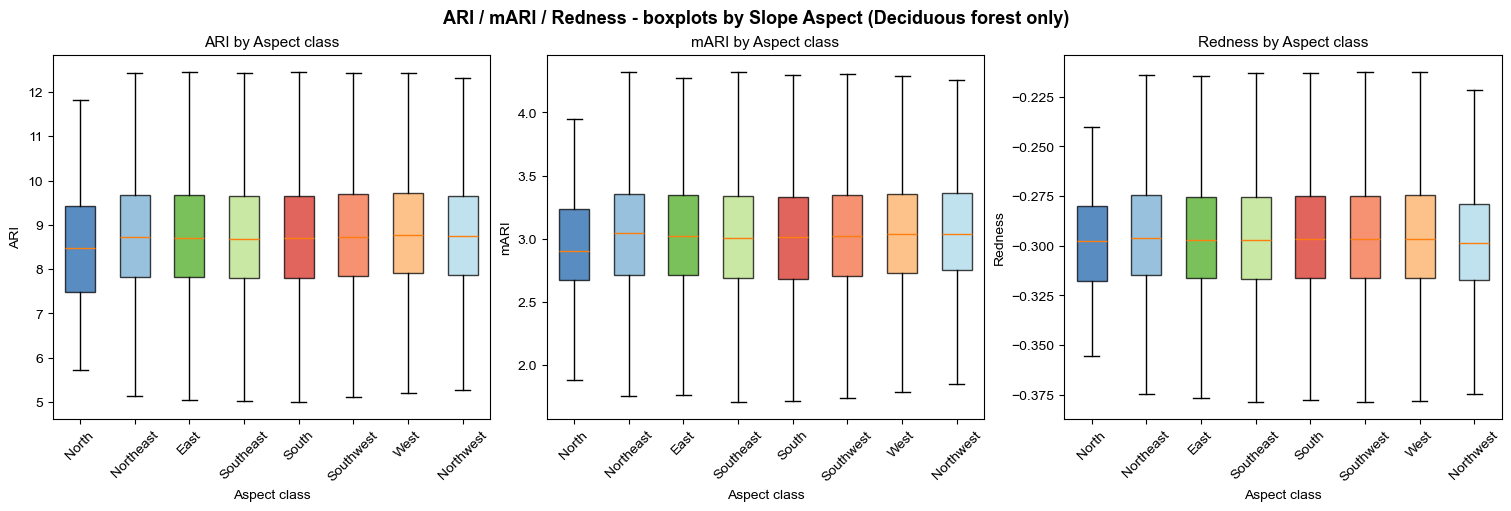

Figure 2 saved.


In [9]:
# -------------------------------------------------------
# FIGURE 2 - Boxplots (aspect class on X, index value on Y)
# -------------------------------------------------------
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for j, col in enumerate(["ARI", "mARI", "Redness"]):
    ax = axes2[j]
    data_by_class = [df.loc[df["aspect_class"] == cls, col].values
                     for cls in present_classes]

    bp = ax.boxplot(
        data_by_class,
        labels       = present_classes,
        showfliers   = False,
        widths       = 0.55,
        patch_artist = True,
    )
    for patch, cls in zip(bp['boxes'], present_classes):
        patch.set_facecolor(color_map[cls])
        patch.set_alpha(0.75)

    ax.set_title(f"{col} by Aspect class", fontsize=11)
    ax.set_xlabel("Aspect class")
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=45)

fig2.suptitle("ARI / mARI / Redness - boxplots by Slope Aspect (Deciduous forest only)",
              fontsize=13, fontweight='bold')
plt.savefig(r"C:\Data_for_Code\ARI_aspect_deciduous_boxplots.png", dpi=200, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

C:\Users\aglyl\AppData\Local\Temp\ipykernel_31352\240900603.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_bot.boxplot(
C:\Users\aglyl\AppData\Local\Temp\ipykernel_31352\240900603.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_bot.boxplot(
C:\Users\aglyl\AppData\Local\Temp\ipykernel_31352\240900603.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_bot.boxplot(


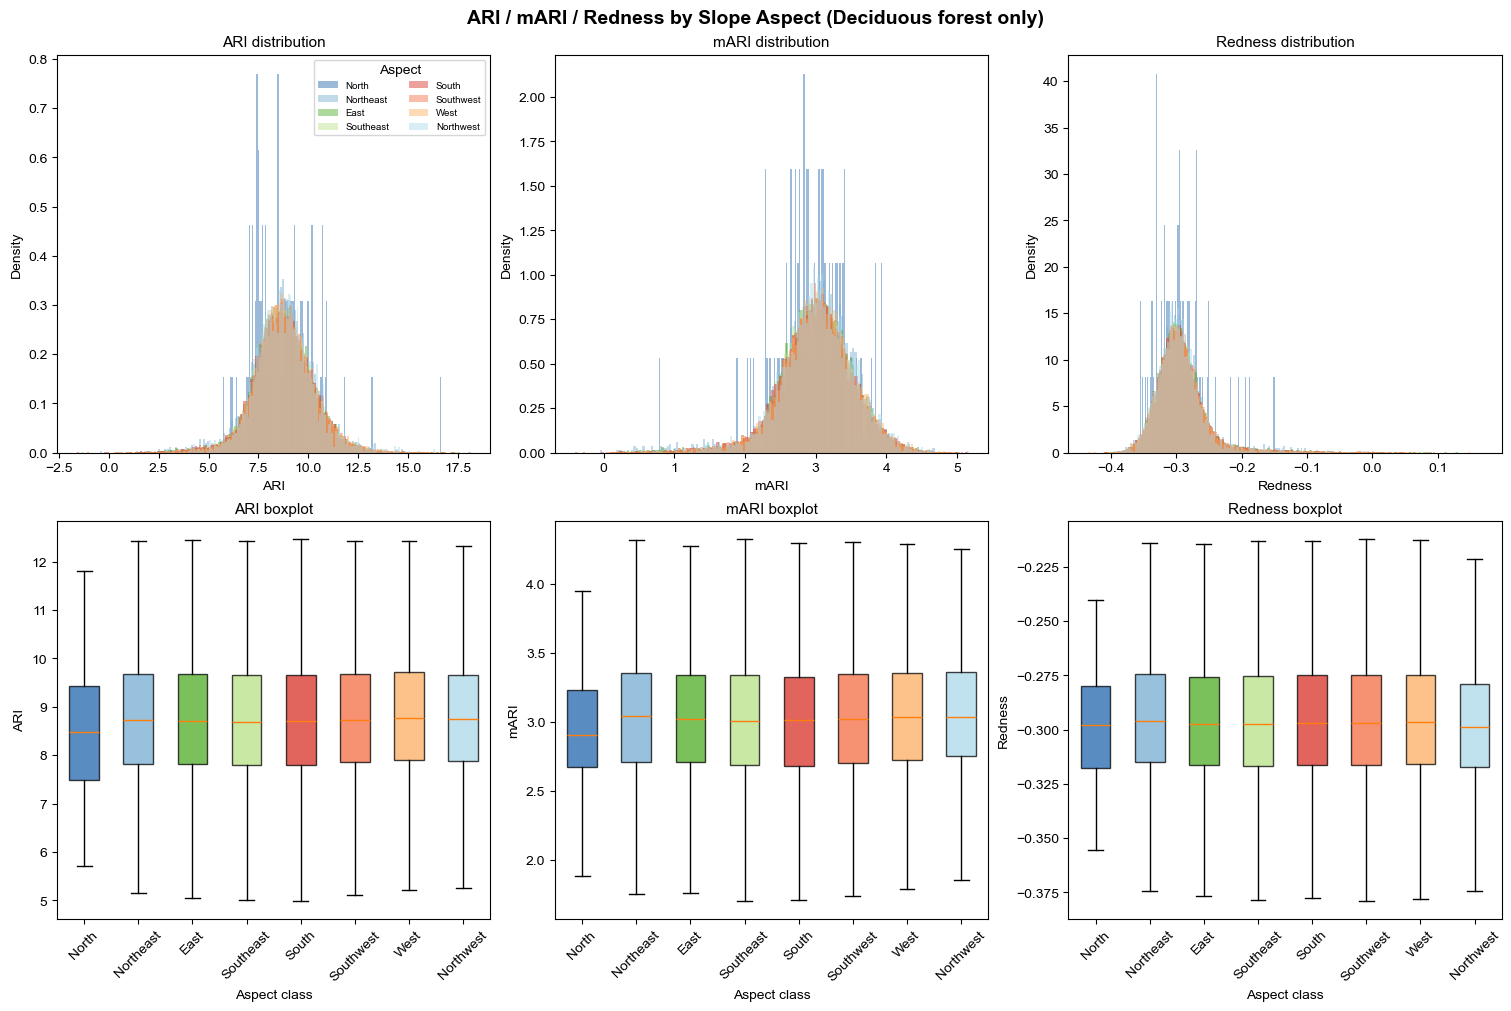

Figure 3 (combined) saved.


In [10]:
# -------------------------------------------------------
# FIGURE 3 - Combined 2x3 panel
# Top row: histograms | Bottom row: boxplots
# Mirrors the layout of the original notebook exactly.
# -------------------------------------------------------
fig3, axes3 = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)

for j, col in enumerate(["ARI", "mARI", "Redness"]):

    # Top row: histograms
    ax_top = axes3[0, j]
    for cls in present_classes:
        vals = df.loc[df["aspect_class"] == cls, col].values
        ax_top.hist(vals, bins=150, alpha=0.45, density=True,
                    color=color_map[cls], label=cls)
    ax_top.set_title(f"{col} distribution", fontsize=11)
    ax_top.set_xlabel(col)
    ax_top.set_ylabel("Density")
    if j == 0:
        ax_top.legend(fontsize=7, ncol=2, title="Aspect")

    # Bottom row: boxplots
    ax_bot = axes3[1, j]
    data_by_class = [df.loc[df["aspect_class"] == cls, col].values
                     for cls in present_classes]
    bp = ax_bot.boxplot(
        data_by_class,
        labels       = present_classes,
        showfliers   = False,
        widths       = 0.55,
        patch_artist = True,
    )
    for patch, cls in zip(bp['boxes'], present_classes):
        patch.set_facecolor(color_map[cls])
        patch.set_alpha(0.75)
    ax_bot.set_title(f"{col} boxplot", fontsize=11)
    ax_bot.set_xlabel("Aspect class")
    ax_bot.set_ylabel(col)
    ax_bot.tick_params(axis='x', rotation=45)

fig3.suptitle("ARI / mARI / Redness by Slope Aspect (Deciduous forest only)",
              fontsize=14, fontweight='bold')
plt.savefig(r"C:\Data_for_Code\ARI_aspect_deciduous_combined.png", dpi=200, bbox_inches='tight')
plt.show()
print("Figure 3 (combined) saved.")

In [11]:
# -------------------------------------------------------
# Summary statistics table
# N, Mean, Median, Std, Q25, Q75 per aspect class per index
# -------------------------------------------------------
records = []
for cls in present_classes:
    sub = df[df["aspect_class"] == cls]
    for col in ["ARI", "mARI", "Redness"]:
        vals = sub[col].dropna().values
        records.append({
            "Aspect"  : cls,
            "Index"   : col,
            "N"       : len(vals),
            "Mean"    : np.mean(vals),
            "Median"  : np.median(vals),
            "Std"     : np.std(vals, ddof=1),
            "Q25"     : np.percentile(vals, 25),
            "Q75"     : np.percentile(vals, 75),
        })

stats_df = pd.DataFrame(records)
print(stats_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

   Aspect   Index     N    Mean  Median    Std     Q25     Q75
    North     ARI    89  8.6576  8.4769 1.6000  7.4885  9.4349
    North    mARI    89  2.9264  2.9063 0.4890  2.6723  3.2334
    North Redness    89 -0.2939 -0.2977 0.0398 -0.3178 -0.2800
Northeast     ARI  2519  8.7068  8.7366 1.6221  7.8238  9.6801
Northeast    mARI  2519  2.9887  3.0464 0.5943  2.7106  3.3556
Northeast Redness  2519 -0.2902 -0.2959 0.0424 -0.3147 -0.2744
     East     ARI 11372  8.7215  8.7121 1.5807  7.8136  9.6698
     East    mARI 11372  3.0020  3.0224 0.5535  2.7089  3.3429
     East Redness 11372 -0.2907 -0.2971 0.0449 -0.3163 -0.2755
Southeast     ARI 18943  8.7068  8.6817 1.5738  7.7994  9.6549
Southeast    mARI 18943  2.9947  3.0088 0.5513  2.6858  3.3417
Southeast Redness 18943 -0.2904 -0.2971 0.0466 -0.3166 -0.2752
    South     ARI 19435  8.7166  8.7120 1.5919  7.7900  9.6596
    South    mARI 19435  2.9864  3.0114 0.5579  2.6824  3.3293
    South Redness 19435 -0.2897 -0.2968 0.0477 -0.3162 